### Assignment 1 code to run

In [1]:
# -----------------------------
# Parameters
# -----------------------------
gamma = 0.9
lam=0.5 # used in poisson distribution
xi1, xi2 = 5, 7

# Location states
DEPOT = 0
AT_1 = 1   # engineer is @ machine 1
AT_2 = 2   # engineer is @ machine 2
REP_1 = 3   # 1 unit of remaining time for corrective maintenance @1. Note that this state only exists when x1=xi1. 
REP_2 = 4   # 1 unit of remaining time for corrective maintenance @2. Note that this state only exists when x2=xi2. 

# -----------------------------
# State space
# -----------------------------

# NOTE: we keep only states that are possible

states = []

for x1 in range(xi1 + 1):
    for x2 in range(xi2 + 1):

        # always allowed locations
        for l in [DEPOT, AT_1, AT_2]:
            states.append((x1, x2, l))

        # corrective maintenance state for machine 1
        if x1 == xi1:
            states.append((x1, x2, REP_1))

        # corrective maintenance state for machine 2
        if x2 == xi2:
            states.append((x1, x2, REP_2))


# -----------------------------
# Poisson probabilities
# -----------------------------
def poisson_pmf(y,lam, max_y):
    """
    Returns the y-th element of the list:
    [P(X=0), P(X=1), ..., P(X=max_y-1), P(X>=max_y)]
    with X ~ Poisson(lam)
    """

    probs = []

    if max_y>0:
        # P(X=0)
        p = math.exp(-lam)
        probs.append(p)

        # Compute P(X=k) recursively
        for k in range(1, max_y):
            p = p * lam / k
            probs.append(p)

        # Tail probability
        tail = 1.0 - sum(probs)
        probs.append(tail)
    elif max_y==0:
        probs=[1]
    return probs[y]

# -----------------------------
# Action space
# -----------------------------
#Note that this is further refined below when considering the possible acitons
ACTIONS = ["nothing", "travel_1", "travel_2", "travel_depot",
           "maintain_1", "maintain_2", "continue maintenance"]


"""
The action "continue maintenance" is a pseudo-action to only indicate that we are forced to continue the corrective maintenance for a second period of time and should not impact the results        
"""    

# -----------------------------
# Feasible actions
# -----------------------------

# used in e-gridy!!!

def feasible_actions(state): 
    # based on a state gets me a function of feasible actions! 
    x1, x2, l = state
    
    acts = []
    
    # forced continuation during repair
    if l in (REP_1, REP_2):
        acts = ["continue maintenance"]

    elif l == DEPOT:
        if x2 == xi2 and x1 == xi1:
            acts = ["travel_1", "travel_2"]
        elif x2 == xi2 and x1 < xi1:
            acts = ["travel_2"]
        elif x1 == xi1 and x2 < xi2:
            acts = ["travel_1"]
        else:
            acts = ["nothing", "travel_1", "travel_2"]

    elif l == AT_1:
        if x1 == xi1:
            acts = ["maintain_1"]
        elif x1 < xi1 and x2 == xi2: 
            acts = ["travel_depot"]
        else:
            acts = ["travel_depot", "maintain_1","nothing"]  
        

    elif l == AT_2:
        if x2 == xi2:
            acts = ["maintain_2"]
        elif x2 < xi2 and x1 == xi1: 
            acts = ["travel_depot"]
        else:
            acts = ["travel_depot", "maintain_2","nothing"] 

    return acts

# -----------------------------
# Cost
# -----------------------------
def cost(state, action):
    x1, x2, l = state

    c = 0

    if action == "maintain_1":
        if x1 < xi1:
            c += 1 
        else:
            c += 5 
                
    if action == "maintain_2":
        if x2 < xi2:
            c += 1 
        else:
            c += 5 

    # unavailability cost
    if x1 == xi1 :
        c += 1
    if x2 == xi2 :
        c += 1

    return c


# -----------------------------
# Transitions
# -----------------------------
def transitions(state, action):
    x1, x2, l = state
    trans = {}

    # ---------------- forced repair completion
    if l == REP_1:
        # in the next unit, maintenance completed → machine 1 becomes healthy
        for y in range(xi2-x2+1):
            p = poisson_pmf(y,lam, xi2-x2)
            x2n = min(x2 + y, xi2)
            trans[(0, x2n, AT_1)] = \
                trans.get((0, x2n, AT_1), 0) + p
        return trans

    elif l == REP_2:
        # in the next unit, maintenance completed → machine 2 becomes healthy
        for y in range(xi1-x1+1):
            p = poisson_pmf(y,lam,xi1-x1)
            x1n = min(x1 + y, xi1)
            trans[(x1n, 0, AT_2)] = \
                trans.get((x1n, 0, AT_2), 0) + p
        return trans

    # ---------------- travel
    elif action == "travel_1":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, AT_1)] = \
                    trans.get((x1n, x2n, AT_1), 0) + p
        return trans

    elif action == "travel_2":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, AT_2)] = \
                    trans.get((x1n, x2n, AT_2), 0) + p
        return trans
    
    elif action == "travel_depot":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, DEPOT)] = \
                    trans.get((x1n, x2n, DEPOT), 0) + p

    # ---------------- maintenance start
    elif action == "maintain_1":
        # preventive = 1 period
        if x1 < xi1:
            for y in range(xi2-x2+1):
                p = poisson_pmf(y,lam, xi2-x2)
                x2n = min(x2 + y, xi2)
                trans[(0, x2n, AT_1)] = \
                    trans.get((0, x2n, AT_1), 0) + p
        elif x1 == xi1:
            # corrective = 2 periods
            for y in range(xi2-x2+1):
                p = poisson_pmf(y,lam,xi2-x2)
                x2n = min(x2 + y, xi2)
                trans[(xi1, x2n, REP_1)] = \
                    trans.get((xi1, x2n, REP_1), 0) + p
        return trans

    elif action == "maintain_2":
        if x2 < xi2:
            for y in range(xi1-x1+1):
                p = poisson_pmf(y,lam,xi1-x1)
                x1n = min(x1 + y, xi1)
                trans[(x1n, 0, AT_2)] = \
                    trans.get((x1n, 0, AT_2), 0) + p
        elif x2==xi2:
            for y in range(xi1-x1+1):
                p = poisson_pmf(y,lam,xi1-x1)
                x1n = min(x1 + y, xi1)
                trans[(x1n, xi2, REP_2)] = \
                    trans.get((x1n, xi2, REP_2), 0) + p
        return trans

    elif action == "nothing":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, l)] = \
                    trans.get((x1n, x2n, l), 0) + p
    return trans

# Assignment 2 — Task 1: Q-Learning for Optimal Maintenance Policy

This notebook implements **Q-Learning** (off-policy TD control) to recover the optimal
maintenance policy for the two-machine system from Assignment 1, using only observed
interactions — no knowledge of transition probabilities is used during training.

**Notebook structure:**
1. Policy Iteration oracle (ground-truth V*)
2. Q-Learning: algorithm design, pseudocode, and justification
3. Training run with motivated hyperparameters + convergence analysis
4. Policy extraction and comparison with PI
5. Hyperparameter sensitivity study

---
**Prerequisites:** Execute the Assignment 1 MDP definition cell **before** running this notebook.  
Required in scope: `states`, `ACTIONS`, `feasible_actions`, `cost`, `transitions`,
`gamma`, `xi1`, `xi2`, `DEPOT`, `AT_1`, `AT_2`, `REP_1`, `REP_2`.

In [2]:
import numpy as np
import random
import math
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1 — Policy Iteration Oracle

We run Policy Iteration with **full model knowledge** to obtain V*(s) — the ground-truth
optimal value function. This serves two purposes:
- **Oracle MSE**: an objective measure of how close Q-Learning converges to the true optimum
- **Policy comparison**: verifying Q-Learning recovers the same decisions

In a real model-free setting we would not have this oracle. We use it here because we
do have the model from Assignment 1, and the assignment explicitly asks for a comparison.

In [3]:
V_PI     = {s: 0.0             for s in states}
policy_PI = {s: feasible_actions(s)[0] for s in states}


def _pi_eval(pol, V, tol=1e-10):
    while True:
        delta = 0.0
        for s in states:
            a     = pol[s]
            v_new = cost(s, a) + gamma * sum(
                p * V[sp] for sp, p in transitions(s, a).items()
            )
            delta = max(delta, abs(V[s] - v_new))
            V[s]  = v_new
        if delta < tol:
            break


def _pi_improve(pol, V):
    stable = True
    for s in states:
        old_a            = pol[s]
        best_a, best_q   = old_a, float("inf")
        for a in feasible_actions(s):
            q = cost(s, a) + gamma * sum(
                p * V[sp] for sp, p in transitions(s, a).items()
            )
            if q < best_q:
                best_q, best_a = q, a
        if best_a != old_a:
            pol[s] = best_a
            stable = False
    return stable


_pi_iters = 0
while True:
    _pi_iters += 1
    _pi_eval(policy_PI, V_PI)
    if _pi_improve(policy_PI, V_PI):
        break

print(f"PI converged in {_pi_iters} iterations")
print(f"V*(0,0,DEPOT) = {V_PI[(0, 0, DEPOT)]:.4f}")
print(f"V*(5,7,DEPOT) = {V_PI[(5, 7, DEPOT)]:.4f}  (worst degradation state)")

PI converged in 5 iterations
V*(0,0,DEPOT) = 2.4620
V*(5,7,DEPOT) = 16.8511  (worst degradation state)


## 3 — Implementation

In [4]:
# ---------------------------------------------------------------------------
# Episode length formula
# Derivation: we want γ^T · R_max / (1−γ) < error
#   → T > log(error·(1−γ)/R_max) / log(γ)
#   → T_max = ceil( log(error·(1−γ)/R_max) / log(γ) )
# R_max = 7: worst single step = both machines failed (cost 2)
#            + corrective maintenance on one (cost 5).
# ---------------------------------------------------------------------------
def getLengthEpisode(gamma_val=0.9, r_max=7.0, error=1e-8):
    return int(np.ceil(
        np.log(error * (1.0 - gamma_val) / r_max) / np.log(gamma_val)
    ))


T_MAX = getLengthEpisode(gamma_val=gamma)
print(f"Episode length: T_MAX = {T_MAX} steps  (γ={gamma}, R_max=7, error=1e-8)")

# Index mappings: state/action → integer row/column in Q-table
states_indexes  = {s: i for i, s in enumerate(states)}
actions_indexes = {a: i for i, a in enumerate(ACTIONS)}

# Pre-compute feasible actions, transition distributions, and costs once.
# All three caches are built here so the inner training loop (T_MAX × n_episodes
# steps) does pure array indexing rather than Python function calls.
feasible_cache = {s: feasible_actions(s) for s in states}

# cost_cache: cost(s,a) is deterministic — cache it to eliminate ~10M Python calls.
cost_cache = {(s, a): cost(s, a) for s in states for a in feasible_cache[s]}

# trans_cache: store next-state lists and pre-normalised numpy probability arrays.
# np.random.choice requires probabilities that sum to exactly 1.0;
# explicit normalisation guards against float rounding errors in Poisson PMFs.
trans_cache = {}
for s in states:
    for a in feasible_cache[s]:
        td    = transitions(s, a)
        p_arr = np.array(list(td.values()), dtype=np.float64)
        p_arr /= p_arr.sum()           # ensure exact sum = 1.0
        trans_cache[(s, a)] = (list(td.keys()), p_arr)

print(f"Cached {len(trans_cache)} feasible (state, action) distributions")
print(f"States: {len(states)},  Actions: {len(ACTIONS)}")

Episode length: T_MAX = 216 steps  (γ=0.9, R_max=7, error=1e-8)
Cached 369 feasible (state, action) distributions
States: 158,  Actions: 7


In [5]:
def qLearning(n_episodes, alpha_power=1.0, epsilon_0=1.0,
              V_oracle=None, mse_interval=200,
              dq_tau=1e-3, consec_threshold=20, seed=None):
    """
    Q-Learning for cost minimisation on the maintenance MDP.

    Parameters
    ----------
    n_episodes        : maximum number of training episodes
    alpha_power       : exponent omega for Robbins-Monro learning rate.
                        alpha_k = 1 / N(s,a)^omega.
                        Valid range: 0.5 < omega <= 1.
                          sum(1/n^omega) diverges      iff omega <= 1  (cond. 1)
                          sum(1/n^2omega) converges    iff omega > 0.5 (cond. 2)
                        omega=1.0 is the standard 1/N schedule.
                        Smaller omega decays alpha more slowly.
    epsilon_0         : initial exploration scale; eps_k = epsilon_0 / (k+1)
                        Decays to 0 satisfying GLIE.
    V_oracle          : dict {state: V*(s)} from PI for oracle MSE tracking
    mse_interval      : episodes between oracle MSE checkpoints
    dq_tau            : convergence threshold on max|delta_Q|
    consec_threshold  : stop when max|delta_Q| < dq_tau for this many
                        consecutive episodes (default 20)
    seed              : random seed for reproducibility

    Returns
    -------
    Q               : ndarray (|S| x |A|), +inf for infeasible entries
    episode_costs   : list[float], total undiscounted cost per episode
    dq_history      : list[float], max |delta_Q| per episode
    mse_checkpoints : list[(episode, mse)]
    conv_episode    : int, episode at which convergence was declared
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Q-table: +inf for infeasible (s,a), 0.0 for feasible
    # visit_count: numpy 2-D array, init to 1 (avoids div-by-zero on first visit)
    Q           = np.full((len(states), len(ACTIONS)), np.inf)
    visit_count = np.ones((len(states), len(ACTIONS)), dtype=np.float64)

    for s_idx, s in enumerate(states):
        for a in feasible_cache[s]:
            Q[s_idx, actions_indexes[a]] = 0.0

    finite_mask = np.isfinite(Q)   # True for feasible (s,a) — never changes

    episode_costs   = []
    dq_history      = []
    mse_checkpoints = []
    conv_episode    = n_episodes
    consec_count    = 0

    for k in tqdm(range(n_episodes), desc="Q-Learning", leave=True):

        Q_before = Q.copy()
        s        = random.choice(states)
        eps_k    = epsilon_0 / (k + 1)   # GLIE: constant within episode
        ep_cost  = 0.0

        for _ in range(T_MAX):
            s_idx = states_indexes[s]

            # epsilon-greedy action selection
            if random.random() < eps_k:
                a = random.choice(feasible_cache[s])           # explore
            else:
                row   = Q[s_idx]
                min_v = np.min(row)
                tied  = np.flatnonzero(row == min_v)
                a     = ACTIONS[int(np.random.choice(tied))]   # exploit (tie-break)

            a_idx = actions_indexes[a]

            r        = cost_cache[(s, a)]          # O(1) — no function call
            ep_cost += r

            next_states, probs = trans_cache[(s, a)]
            s_new = next_states[np.random.choice(len(next_states), p=probs)]

            # Q-Learning update (cost minimisation: min not max)
            # alpha_k = 1 / N(s,a)^omega  — Robbins-Monro schedule
            s_new_idx = states_indexes[s_new]
            next_min  = np.min(Q[s_new_idx])
            alpha_k   = visit_count[s_idx, a_idx] ** (-alpha_power)

            Q[s_idx, a_idx] += alpha_k * (r + gamma * next_min - Q[s_idx, a_idx])
            visit_count[s_idx, a_idx] += 1
            s = s_new

        # --- end of episode ---
        episode_costs.append(ep_cost)

        dq = float(np.max(np.abs(Q[finite_mask] - Q_before[finite_mask])))
        dq_history.append(dq)

        if V_oracle is not None and k % mse_interval == 0:
            V_ql  = np.array([np.min(Q[states_indexes[s]]) for s in states])
            V_ref = np.array([V_oracle[s]                  for s in states])
            mse_checkpoints.append((k, float(np.mean((V_ql - V_ref) ** 2))))

        # Consecutive convergence check
        if dq < dq_tau:
            consec_count += 1
            if consec_count >= consec_threshold:
                conv_episode = k
                break
        else:
            consec_count = 0

    return Q, episode_costs, dq_history, mse_checkpoints, conv_episode


In [6]:
def extract_policy(Q):
    """
    Extract greedy policy from Q-table.
    Uses random tie-breaking when multiple actions share the minimum Q-value.
    This prevents systematic bias in near-tie states.
    """
    pi = {}
    for s in states:
        row   = Q[states_indexes[s]]
        min_v = np.min(row)
        tied  = np.flatnonzero(row == min_v)
        pi[s] = ACTIONS[int(np.random.choice(tied))]
    return pi


def print_policy_table(policy_dict, location, title=""):
    """Display policy as a DataFrame (rows=x1, cols=x2) for a given engineer location."""
    rows = []
    for x1 in range(xi1 + 1):
        row = []
        for x2 in range(xi2 + 1):
            s = (x1, x2, location)
            row.append(policy_dict.get(s, "N/A"))
        rows.append(row)
    df = pd.DataFrame(
        rows,
        index   = [f"x1={i}" for i in range(xi1 + 1)],
        columns = [f"x2={j}" for j in range(xi2 + 1)],
    )
    print(f"\n{title}")
    print(df.to_string())

## 4 — Training Run

We train with the theoretically motivated hyperparameters:
- **α₀ = 1**: effective learning rate = 1/N(s,a), satisfying both Robbins-Monro conditions
- **ε₀ = 1**: exploration rate = 1/(k+1), satisfying GLIE

The oracle V_PI is passed in to enable MSE tracking every 100 episodes.

In [7]:
Q_main, costs_main, dq_main, mse_main, conv_main = qLearning(
    n_episodes       = 60_000,
    alpha_power      = 0.7,
    epsilon_0        = 0.5,
    V_oracle         = V_PI,
    mse_interval     = 200,
    dq_tau           = 1e-4,
    consec_threshold = 20,
    seed             = 42,
)

print(f"\nConverged at episode : {conv_main}")
print(f"Episodes run         : {len(costs_main)}")
print(f"Mean cost (last 500) : {np.mean(costs_main[-500:]):.4f}")
print(f"Final delta_Q        : {dq_main[-1]:.2e}")
if mse_main:
    print(f"Final oracle MSE     : {mse_main[-1][1]:.6f}")


Q-Learning:   0%|          | 0/60000 [00:00<?, ?it/s]


Converged at episode : 60000
Episodes run         : 60000
Mean cost (last 500) : 86.6420
Final delta_Q        : 4.72e-03
Final oracle MSE     : 0.003332


## 5 — Convergence Analysis

Three complementary views of convergence:
1. **Episode cost** — shows the agent improving over time
2. **ΔQ (log scale)** — shows Q-values stabilising; this is our stopping criterion
3. **Oracle MSE** — measures closeness to the true V* from PI

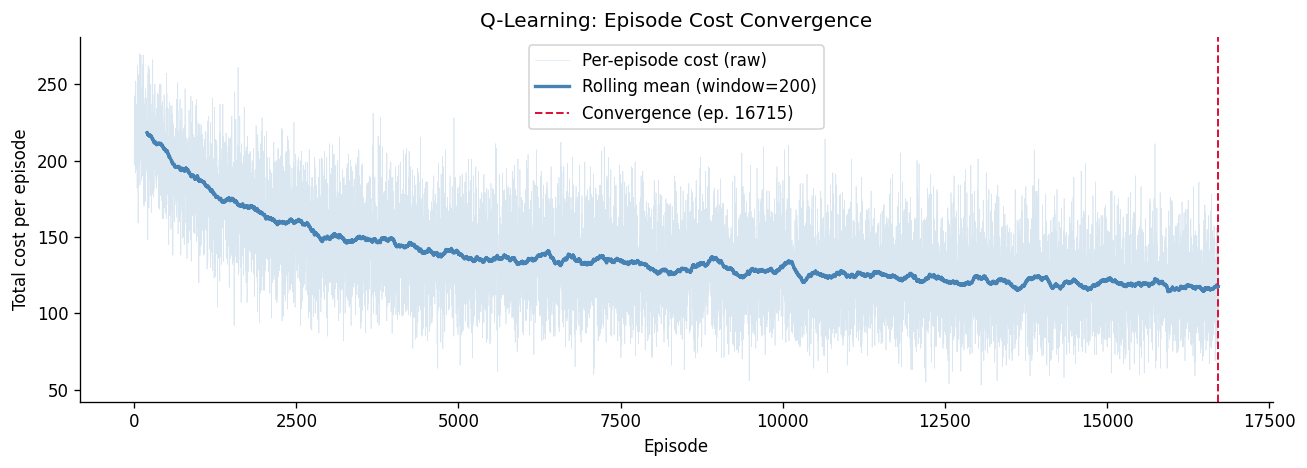

In [ ]:
# Figure 1: Per-episode total cost
fig, ax = plt.subplots(figsize=(11, 4))

window   = 200
smoothed = np.convolve(costs_main, np.ones(window) / window, mode="valid")
x_smooth = np.arange(window - 1, len(costs_main))

ax.plot(costs_main, color="steelblue", alpha=0.2, linewidth=0.4, label="Per-episode cost (raw)")
ax.plot(x_smooth, smoothed, color="steelblue", linewidth=2,
        label=f"Rolling mean (window={window})")
ax.axvline(conv_main, color="crimson", linestyle="--", linewidth=1.2,
           label=f"Convergence (ep. {conv_main})")

ax.set_xlabel("Episode")
ax.set_ylabel("Total cost per episode")
ax.set_title("Q-Learning: Episode Cost Convergence")
ax.legend()
plt.tight_layout()
plt.savefig("fig_episode_costs.pdf", bbox_inches="tight")
plt.show()

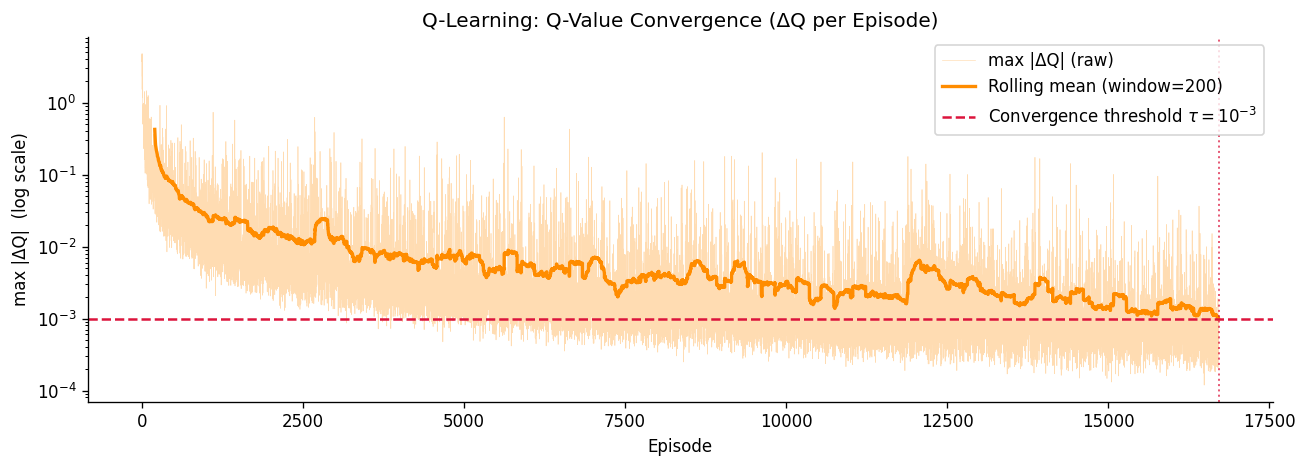

In [ ]:
# Figure 2: delta_Q per episode (log scale) — our primary convergence metric
fig, ax = plt.subplots(figsize=(11, 4))

ax.semilogy(dq_main, color="darkorange", alpha=0.3, linewidth=0.4, label="max |ΔQ| (raw)")

if len(dq_main) >= 200:
    dq_smooth = np.convolve(dq_main, np.ones(200) / 200, mode="valid")
    ax.semilogy(np.arange(199, len(dq_main)), dq_smooth,
                color="darkorange", linewidth=2, label="Rolling mean (window=200)")

ax.axhline(1e-3, color="crimson", linestyle="--", linewidth=1.5,
           label=r"Convergence threshold $\tau=10^{-3}$")
ax.axvline(conv_main, color="crimson", linestyle=":", linewidth=1.2, alpha=0.7)

ax.set_xlabel("Episode")
ax.set_ylabel("max |ΔQ|  (log scale)")
ax.set_title("Q-Learning: Q-Value Convergence (ΔQ per Episode)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_delta_q.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Figure 3: Oracle MSE — how close V_QL(s) = min_a Q(s,a) is to V*(s)
if mse_main:
    eps_idx, mse_vals = zip(*mse_main)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.semilogy(eps_idx, mse_vals, color="seagreen", linewidth=1.5,
                marker=".", markersize=2, label="Oracle MSE")
    ax.axvline(conv_main, color="crimson", linestyle="--", linewidth=1.2,
               label=f"Convergence (ep. {conv_main})")

    ax.set_xlabel("Episode")
    ax.set_ylabel(r"$\mathbb{E}_s[(V_{QL}(s) - V^*(s))^2]$  (log scale)")
    ax.set_title("Q-Learning: Oracle MSE vs. Policy Iteration Ground Truth")
    ax.legend()
    plt.tight_layout()
    plt.savefig("fig_oracle_mse.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Oracle not provided — MSE plot skipped.")

## 6 — Optimal Policy

We extract the greedy policy $\pi^*(s) = \arg\min_a Q(s,a)$ and display it in the
same table format as Assignment 1 for direct comparison.

**Note on REP states** (REP_1, REP_2): these have a single forced action
(`continue maintenance`) and are excluded from the comparison tables — they always
match by construction.

In [ ]:
policy_QL = extract_policy(Q_main)

loc_names = {
    DEPOT: "DEPOT",
    AT_1 : "AT Machine 1",
    AT_2 : "AT Machine 2",
}

print("=" * 60)
print("Q-LEARNING POLICY")
print("=" * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_QL, loc, f"Q-Learning — {name}")

print()
print("=" * 60)
print("POLICY ITERATION POLICY  (ground truth)")
print("=" * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_PI, loc, f"PI — {name}")

Q-LEARNING POLICY

Q-Learning — DEPOT
          x2=0      x2=1      x2=2      x2=3      x2=4      x2=5      x2=6      x2=7
x1=0  travel_1  travel_2   nothing  travel_2  travel_2  travel_2  travel_2  travel_2
x1=1   nothing  travel_1   nothing   nothing  travel_2  travel_2  travel_2  travel_2
x1=2  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2
x1=3  travel_1  travel_1  travel_1  travel_1  travel_1   nothing  travel_1  travel_2
x1=4  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2
x1=5  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2

Q-Learning — AT Machine 1
              x2=0        x2=1          x2=2          x2=3          x2=4          x2=5          x2=6          x2=7
x1=0  travel_depot     nothing  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot
x1=1       nothing     nothing  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_d

In [ ]:
# Policy comparison: QL vs PI
# Near-tie threshold: if the Q-value gap between the best and second-best
# action is below this, both actions are essentially equivalent.
NEAR_TIE_THRESHOLD = 0.05

exact_matches  = 0
near_tie_diffs = []
true_mismatches = []

for s in states:
    if s[2] in (REP_1, REP_2):
        continue  # forced-action states always match

    s_idx    = states_indexes[s]
    row      = Q_main[s_idx]
    fin_vals = np.sort(row[np.isfinite(row)])

    pi_action = policy_PI[s]
    ql_action = policy_QL[s]

    if pi_action == ql_action:
        exact_matches += 1
    else:
        gap   = float(fin_vals[1] - fin_vals[0]) if len(fin_vals) > 1 else 0.0
        entry = (s, pi_action, ql_action, gap)
        if gap < NEAR_TIE_THRESHOLD:
            near_tie_diffs.append(entry)
        else:
            true_mismatches.append(entry)

total = sum(1 for s in states if s[2] not in (REP_1, REP_2))

print(f"Non-forced states     : {total}")
print(f"Exact matches         : {exact_matches}  ({100 * exact_matches / total:.1f}%)")
print(f"Near-tie differences  : {len(near_tie_diffs)}  (Q-gap < {NEAR_TIE_THRESHOLD})")
print(f"True mismatches       : {len(true_mismatches)}")

if near_tie_diffs:
    print("\nNear-tie differences (both actions are essentially equivalent):")
    for s, pi_a, ql_a, gap in near_tie_diffs:
        print(f"  {s}:  PI={pi_a:<20s}  QL={ql_a:<20s}  Q-gap={gap:.4f}")

if true_mismatches:
    print("\nTrue mismatches (investigate these):")
    for s, pi_a, ql_a, gap in true_mismatches:
        print(f"  {s}:  PI={pi_a:<20s}  QL={ql_a:<20s}  Q-gap={gap:.4f}")

# Assignment 2 — Task 2: Double Q-Learning

This notebook builds directly on Task 1. We:

1. **Demonstrate minimisation bias** in the Task 1 Q-Learning solution
2. **Implement Double Q-Learning** to correct it
3. **Compare** convergence, bias, policy match, and value function MSE

**Prerequisites:** Run all cells in `task1_qlearning.ipynb` first so that
`states`, `ACTIONS`, `feasible_actions`, `cost`, `transitions`, `gamma`,
`xi1`, `xi2`, `DEPOT`, `AT_1`, `AT_2`, `REP_1`, `REP_2`,
`V_PI`, `policy_PI`, `states_indexes`, `actions_indexes`,
`feasible_cache`, `cost_cache`, `trans_cache`, `T_MAX`,
`extract_policy`, `print_policy_table` are all in scope.

Also run the main training cell so `Q_main` (Task 1 converged Q-table) is available.

In [8]:
import numpy as np
import random
import math
import os
import json as _json
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as _cm

random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1 — Minimisation Bias in Standard Q-Learning

### Theoretical Argument

Standard Q-Learning uses the same Q-table for **both** selecting and evaluating
the best next action:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma\cdot\min_{a'} Q(s',a') - Q(s,a)\bigr]$$

The term $\min_{a'} Q(s',a')$ is a **biased estimator** of the true minimum value.
Because estimates $Q(s',a')$ are noisy, Jensen's inequality gives:

$$\mathbb{E}\bigl[\min_{a} Q(s,a)\bigr] \;\leq\; \min_{a}\,\mathbb{E}[Q(s,a)] = \min_a q^*(s,a)$$

The minimum of noisy estimates is **systematically lower** than the true minimum.
This is **minimisation bias** — the cost-minimisation analogue of the maximisation bias
described in Sutton & Barto §6.7.

### Why It Matters

Biased Q-values produce a biased value function $V_{QL}(s) = \min_a Q(s,a)$.
States whose true costs are similar will have their Q-values pulled down by noise,
causing the algorithm to over-commit to certain actions and potentially yielding a
sub-optimal policy even after convergence.

## 2 — Double Q-Learning: Fixing the Bias

### The Core Idea

Double Q-Learning (van Hasselt, 2010) decouples **action selection** from
**action evaluation** using two independent Q-tables $Q_1$ and $Q_2$:

- With probability 0.5: $Q_1$ selects the greedy action, $Q_2$ evaluates it:

$$Q_1(s,a) \leftarrow Q_1(s,a) + \alpha_1\Bigl[r + \gamma\cdot Q_2\bigl(s',\arg\min_{a'} Q_1(s',a')\bigr) - Q_1(s,a)\Bigr]$$

- With probability 0.5: $Q_2$ selects, $Q_1$ evaluates:

$$Q_2(s,a) \leftarrow Q_2(s,a) + \alpha_2\Bigl[r + \gamma\cdot Q_1\bigl(s',\arg\min_{a'} Q_2(s',a')\bigr) - Q_2(s,a)\Bigr]$$

Because selection and evaluation use **independent** samples, the estimator is unbiased:

$$\mathbb{E}\bigl[Q_2(s', \arg\min_{a'} Q_1(s',a'))\bigr] = q^*\bigl(s', \arg\min_{a'} q^*(s',a')\bigr)$$

### Separate Visit Counters — Why It Matters

Each table is updated only ~50% of steps. Using a **shared** counter $N(s,a)$ would
apply $\alpha = 1/N^\omega$ where $N$ counts **both** tables' updates combined —
effectively halving the learning rate for each table relative to what Robbins-Monro
requires. With **separate** counters $N_1$ and $N_2$:

- $N_1(s,a)$ tracks only $Q_1$ updates → correct R-M schedule for $Q_1$
- $N_2(s,a)$ tracks only $Q_2$ updates → correct R-M schedule for $Q_2$

This is the most common implementation error in Double Q-Learning.

### Action Selection Uses Combined Table

The **behaviour policy** (ε-greedy) uses $Q_1 + Q_2$ so that both tables
contribute to exploration decisions. The combined average represents the
best current estimate of $q^*$.

### Pseudocode

```
INPUT  : K (max episodes), omega, epsilon_0
INIT   : Q1[s,a] = Q2[s,a] = +inf  for infeasible (s,a)
         Q1[s,a] = Q2[s,a] =  0    for feasible   (s,a)
         N1[s,a] = N2[s,a] =  1    separate visit counters
         consec  = 0

FOR k = 1 ... K:
    s    <- Uniform(S)
    eps_k <- epsilon_0 / (k+1)

    FOR t = 0 ... T_max-1:
        // Behaviour policy: eps-greedy on combined Q1+Q2
        IF random() < eps_k:
            a <- random feasible action                   (explore)
        ELSE:
            a <- argmin_a [Q1[s,a] + Q2[s,a]]            (exploit, tie-break)

        r  <- cost(s, a)
        s' <- sample from P(.|s,a)

        // Coin flip: which table updates?
        IF random() < 0.5:
            a* <- argmin_a Q1[s',a]                      (Q1 selects)
            alpha <- N1[s,a]^(-omega)
            Q1[s,a] <- Q1[s,a] + alpha*(r + gamma*Q2[s',a*] - Q1[s,a])
            N1[s,a] <- N1[s,a] + 1                       (only N1 increments)
        ELSE:
            a* <- argmin_a Q2[s',a]                      (Q2 selects)
            alpha <- N2[s,a]^(-omega)
            Q2[s,a] <- Q2[s,a] + alpha*(r + gamma*Q1[s',a*] - Q2[s,a])
            N2[s,a] <- N2[s,a] + 1                       (only N2 increments)
        s <- s'

    // Convergence: monitor combined average table
    Q_avg_k <- (Q1 + Q2) / 2
    dq <- max_{feasible (s,a)} |Q_avg_k - Q_avg_{k-1}|
    IF dq < tau  ->  consec += 1;  IF consec >= C: STOP
    ELSE         ->  consec  = 0

RETURN Q1, Q2;  pi*(s) = argmin_a [Q1+Q2][s,a]
```

### Hyperparameter Justification

| Parameter | Value | Justification |
|---|---|---|
| omega = 1.0 | `alpha_power=1.0` | Same R-M range as Task 1: 0.5 < omega <= 1. Each table updated ~50% of steps, so same omega gives correct per-table schedule. |
| epsilon_0 = 1.0 | `epsilon_0=1.0` | Same GLIE schedule; behaviour policy structure unchanged. |
| T_max = 216 | derived | Identical tail bound — same MDP, same gamma, R_max. |
| tau = 1e-3 | `dq_tau=1e-3` | Same scale as Task 1; monitored on combined average. |
| C = 20 | `consec_threshold=20` | Same robustness argument as Task 1. |
| n_episodes | 2x Task 1 | Each table trained on ~50% of steps; expect ~2x episodes for same convergence quality. |

In [10]:
def doubleQLearning(n_episodes, alpha_power=1.0, epsilon_0=1.0,
                    V_oracle=None, mse_interval=200,
                    dq_tau=1e-3, consec_threshold=20, seed=None):
    """
    Double Q-Learning for cost minimisation on the maintenance MDP.

    Two independent Q-tables Q1 and Q2 decouple action selection from
    action evaluation, eliminating minimisation bias.

    Key differences from qLearning():
      - Two Q-tables (Q1, Q2), each init to 0 for feasible entries
      - Two separate visit counters (N1, N2) — one per table
        (shared counter would apply wrong R-M schedule to each table)
      - Behaviour policy uses argmin(Q1+Q2)  — combined estimate
      - Each step: coin flip decides which table updates
        Q1 updates: a* = argmin Q1[s'], target uses Q2[s',a*]
        Q2 updates: a* = argmin Q2[s'], target uses Q1[s',a*]
      - Convergence monitored on combined average (Q1+Q2)/2

    Parameters
    ----------
    n_episodes        : maximum number of training episodes
    alpha_power       : omega in 1/N^omega; valid range 0.5 < omega <= 1
    epsilon_0         : GLIE scale; eps_k = epsilon_0 / (k+1)
    V_oracle          : dict {state: V*(s)} from PI for MSE tracking
    mse_interval      : episodes between MSE checkpoints
    dq_tau            : convergence threshold on max|delta_Q_avg|
    consec_threshold  : consecutive episodes below dq_tau to stop
    seed              : random seed

    Returns
    -------
    Q1, Q2          : each ndarray (|S| x |A|), +inf for infeasible
    episode_costs   : list[float]
    dq_history      : list[float], max|delta of (Q1+Q2)/2| per episode
    mse_checkpoints : list[(episode, mse)]
    conv_episode    : int
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    n_s = len(states)
    n_a = len(ACTIONS)

    # Initialise both Q-tables: +inf for infeasible, 0.0 for feasible
    Q1 = np.full((n_s, n_a), np.inf)
    Q2 = np.full((n_s, n_a), np.inf)

    # Separate visit counters — critical for correct R-M schedule per table
    N1 = np.ones((n_s, n_a), dtype=np.float64)
    N2 = np.ones((n_s, n_a), dtype=np.float64)

    for s_idx, s in enumerate(states):
        for a in feasible_cache[s]:
            Q1[s_idx, actions_indexes[a]] = 0.0
            Q2[s_idx, actions_indexes[a]] = 0.0

    finite_mask = np.isfinite(Q1)   # same pattern for Q1 and Q2

    episode_costs   = []
    dq_history      = []
    mse_checkpoints = []
    conv_episode    = n_episodes
    consec_count    = 0

    for k in tqdm(range(n_episodes), desc='Double Q-Learning', leave=True):

        Q_avg_before = (Q1 + Q2) / 2.0   # snapshot of combined average for delta_Q
        s       = random.choice(states)
        eps_k   = epsilon_0 / (k + 1)
        ep_cost = 0.0

        for _ in range(T_MAX):
            s_idx = states_indexes[s]

            # Behaviour policy: eps-greedy on combined Q1+Q2
            if random.random() < eps_k:
                a = random.choice(feasible_cache[s])               # explore
            else:
                combined = Q1[s_idx] + Q2[s_idx]
                min_v    = np.min(combined)
                tied     = np.flatnonzero(combined == min_v)
                a        = ACTIONS[int(np.random.choice(tied))]    # exploit

            a_idx = actions_indexes[a]

            r        = cost_cache[(s, a)]
            ep_cost += r

            next_states, probs = trans_cache[(s, a)]
            s_new     = next_states[np.random.choice(len(next_states), p=probs)]
            s_new_idx = states_indexes[s_new]

            # Coin flip: which table gets updated this step?
            if random.random() < 0.5:
                # Q1 updates: Q1 selects greedy action, Q2 evaluates it
                best_a_idx = int(np.argmin(Q1[s_new_idx]))        # Q1 selects
                target     = r + gamma * Q2[s_new_idx, best_a_idx]  # Q2 evaluates
                alpha      = N1[s_idx, a_idx] ** (-alpha_power)
                Q1[s_idx, a_idx] += alpha * (target - Q1[s_idx, a_idx])
                N1[s_idx, a_idx] += 1                              # only N1 increments
            else:
                # Q2 updates: Q2 selects greedy action, Q1 evaluates it
                best_a_idx = int(np.argmin(Q2[s_new_idx]))        # Q2 selects
                target     = r + gamma * Q1[s_new_idx, best_a_idx]  # Q1 evaluates
                alpha      = N2[s_idx, a_idx] ** (-alpha_power)
                Q2[s_idx, a_idx] += alpha * (target - Q2[s_idx, a_idx])
                N2[s_idx, a_idx] += 1                              # only N2 increments

            s = s_new

        # --- end of episode ---
        episode_costs.append(ep_cost)

        # Convergence on combined average table
        Q_avg = (Q1 + Q2) / 2.0
        dq    = float(np.max(np.abs(Q_avg[finite_mask] - Q_avg_before[finite_mask])))
        dq_history.append(dq)

        # Oracle MSE: V_DQL(s) = min_a (Q1+Q2)[s,a] / 2 vs V*(s)
        if V_oracle is not None and k % mse_interval == 0:
            V_dql = np.array([float(np.min(Q_avg[states_indexes[s]])) for s in states])
            V_ref = np.array([V_oracle[s] for s in states])
            mse_checkpoints.append((k, float(np.mean((V_dql - V_ref) ** 2))))

        if dq < dq_tau:
            consec_count += 1
            if consec_count >= consec_threshold:
                conv_episode = k
                break
        else:
            consec_count = 0

    return Q1, Q2, episode_costs, dq_history, mse_checkpoints, conv_episode


def extract_policy_dql(Q1, Q2):
    """Extract greedy policy from combined Q1+Q2 table with random tie-breaking."""
    pi = {}
    for s in states:
        s_idx    = states_indexes[s]
        combined = Q1[s_idx] + Q2[s_idx]
        min_v    = np.min(combined)
        tied     = np.flatnonzero(combined == min_v)
        pi[s]    = ACTIONS[int(np.random.choice(tied))]
    return pi

## 3 — Training Run

We use the same motivated hyperparameters as Task 1 (`alpha_power=1.0`, `epsilon_0=1.0`)
and double the episode budget since each table receives ~50% of updates.

In [11]:
Q1_main, Q2_main, costs_dql, dq_dql, mse_dql, conv_dql = doubleQLearning(
    n_episodes       = 30_000,
    alpha_power      = 1,
    epsilon_0        = 1.0,
    V_oracle         = V_PI,
    mse_interval     = 200,
    dq_tau           = 1e-3,
    consec_threshold = 20,
    seed             = 42,
)

print(f'\nConverged at episode : {conv_dql}')
print(f'Episodes run         : {len(costs_dql)}')
print(f'Mean cost (last 500) : {np.mean(costs_dql[-500:]):.4f}')
print(f'Final delta_Q_avg    : {dq_dql[-1]:.2e}')
if mse_dql:
    print(f'Final oracle MSE     : {mse_dql[-1][1]:.6f}')

Double Q-Learning:   0%|          | 0/30000 [00:00<?, ?it/s]


Converged at episode : 19025
Episodes run         : 19026
Mean cost (last 500) : 86.0580
Final delta_Q_avg    : 8.36e-04
Final oracle MSE     : 0.523545


## 4 — Convergence Analysis

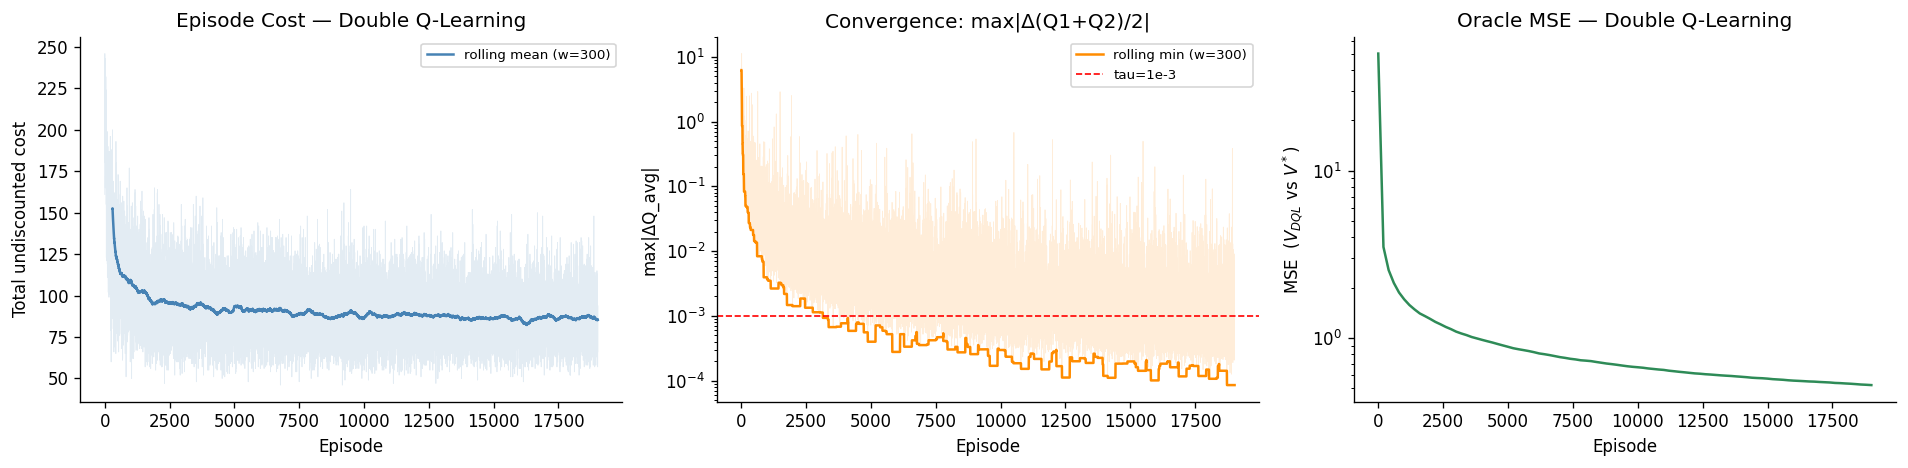

In [12]:
window = 300

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Episode cost
ax = axes[0]
sm = np.convolve(costs_dql, np.ones(window)/window, mode='valid')
ax.plot(costs_dql, alpha=0.15, color='steelblue', linewidth=0.5)
ax.plot(np.arange(window-1, len(costs_dql)), sm, color='steelblue', linewidth=1.5,
        label=f'rolling mean (w={window})')
ax.set_xlabel('Episode')
ax.set_ylabel('Total undiscounted cost')
ax.set_title('Episode Cost — Double Q-Learning')
ax.legend(fontsize=8)

# Panel 2: max|delta_Q_avg| log scale with rolling min
ax = axes[1]
roll_min = [np.min(dq_dql[max(0, j-window):j+1]) for j in range(len(dq_dql))]
ax.semilogy(dq_dql,   alpha=0.15, color='darkorange', linewidth=0.5)
ax.semilogy(roll_min, color='darkorange', linewidth=1.5, label=f'rolling min (w={window})')
ax.axhline(1e-3, color='red', ls='--', lw=1, label='tau=1e-3')
ax.set_xlabel('Episode')
ax.set_ylabel('max|\u0394Q_avg|')
ax.set_title('Convergence: max|\u0394(Q1+Q2)/2|')
ax.legend(fontsize=8)

# Panel 3: Oracle MSE
ax = axes[2]
if mse_dql:
    ep_idx, mse_vals = zip(*mse_dql)
    ax.semilogy(ep_idx, mse_vals, color='seagreen', linewidth=1.5)
    ax.set_xlabel('Episode')
    ax.set_ylabel('MSE  ($V_{DQL}$ vs $V^*$)')
    ax.set_title('Oracle MSE — Double Q-Learning')

plt.tight_layout()
plt.savefig('fig_dql_convergence.pdf', bbox_inches='tight')
plt.show()

## 5 — Bias Comparison: Q-Learning vs Double Q-Learning

── Double Q-Learning bias vs PI oracle ──
Mean error  (V_DQL - V_PI) : -0.3082
Median error               : -0.0467
Std deviation              : 0.6692
% states underestimated    : 54.2%

── Bias reduction summary ──
|Mean error| Q-Learning    : 0.0058
|Mean error| Double QL     : 0.3082
MSE Q-Learning             : 0.0037
MSE Double Q-Learning      : 0.5428


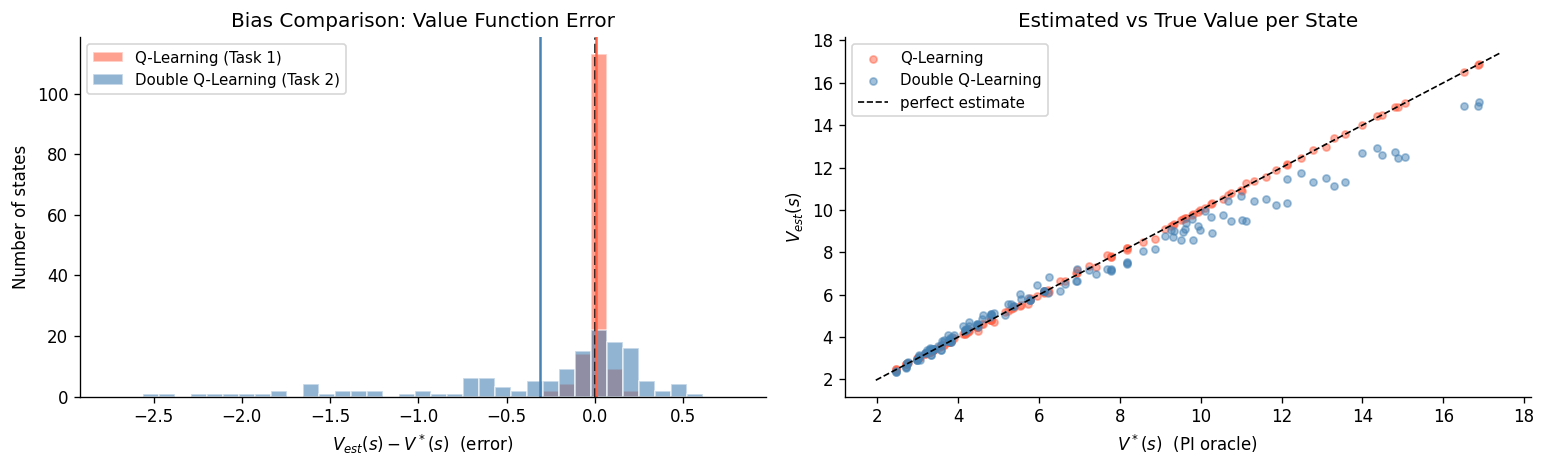

In [13]:
Q_avg_main = (Q1_main + Q2_main) / 2.0
V_DQL      = {s: float(np.min(Q_avg_main[states_indexes[s]])) for s in states}

errors_dql = [V_DQL[s] - V_PI[s] for s in eval_states]

print('── Double Q-Learning bias vs PI oracle ──')
print(f'Mean error  (V_DQL - V_PI) : {np.mean(errors_dql):+.4f}')
print(f'Median error               : {np.median(errors_dql):+.4f}')
print(f'Std deviation              : {np.std(errors_dql):.4f}')
print(f'% states underestimated    : {100*np.mean(np.array(errors_dql) < 0):.1f}%')

print()
print('── Bias reduction summary ──')
print(f'|Mean error| Q-Learning    : {abs(np.mean(errors_t1)):.4f}')
print(f'|Mean error| Double QL     : {abs(np.mean(errors_dql)):.4f}')
print(f'MSE Q-Learning             : {np.mean(np.array(errors_t1)**2):.4f}')
print(f'MSE Double Q-Learning      : {np.mean(np.array(errors_dql)**2):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overlapping histograms
ax = axes[0]
bins = np.linspace(
    min(min(errors_t1), min(errors_dql)) - 0.2,
    max(max(errors_t1), max(errors_dql)) + 0.2,
    40
)
ax.hist(errors_t1,  bins=bins, alpha=0.6, color='tomato',    label='Q-Learning (Task 1)',       edgecolor='white')
ax.hist(errors_dql, bins=bins, alpha=0.6, color='steelblue', label='Double Q-Learning (Task 2)', edgecolor='white')
ax.axvline(0,                     color='black',     lw=1.5, ls='--')
ax.axvline(np.mean(errors_t1),    color='tomato',    lw=1.5, ls='-')
ax.axvline(np.mean(errors_dql),   color='steelblue', lw=1.5, ls='-')
ax.set_xlabel('$V_{est}(s) - V^*(s)$  (error)')
ax.set_ylabel('Number of states')
ax.set_title('Bias Comparison: Value Function Error')
ax.legend(fontsize=9)

# Scatter: V_QL vs V_DQL per state
ax = axes[1]
v_pi_vals  = [V_PI[s]   for s in eval_states]
v_ql_vals  = [V_QL_t1[s] for s in eval_states]
v_dql_vals = [V_DQL[s]  for s in eval_states]
ax.scatter(v_pi_vals, v_ql_vals,  alpha=0.5, s=18, color='tomato',    label='Q-Learning')
ax.scatter(v_pi_vals, v_dql_vals, alpha=0.5, s=18, color='steelblue', label='Double Q-Learning')
lims = [min(v_pi_vals)-0.5, max(v_pi_vals)+0.5]
ax.plot(lims, lims, 'k--', lw=1, label='perfect estimate')
ax.set_xlabel('$V^*(s)$  (PI oracle)')
ax.set_ylabel('$V_{est}(s)$')
ax.set_title('Estimated vs True Value per State')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_bias_comparison.pdf', bbox_inches='tight')
plt.show()

## 6 — Optimal Policy

In [14]:
policy_DQL = extract_policy_dql(Q1_main, Q2_main)

loc_names = {DEPOT: 'DEPOT', AT_1: 'AT Machine 1', AT_2: 'AT Machine 2'}

print('=' * 60)
print('DOUBLE Q-LEARNING POLICY')
print('=' * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_DQL, loc, f'Double QL — {name}')

print()
print('=' * 60)
print('POLICY ITERATION POLICY  (ground truth)')
print('=' * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_PI, loc, f'PI — {name}')

DOUBLE Q-LEARNING POLICY

Double QL — DEPOT
          x2=0      x2=1      x2=2      x2=3      x2=4      x2=5      x2=6      x2=7
x1=0  travel_1  travel_1   nothing  travel_2  travel_2  travel_2  travel_2  travel_2
x1=1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2  travel_2  travel_2
x1=2  travel_1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2  travel_2
x1=3  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2
x1=4  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2
x1=5  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1

Double QL — AT Machine 1
            x2=0        x2=1          x2=2          x2=3          x2=4          x2=5          x2=6          x2=7
x1=0     nothing     nothing  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot
x1=1     nothing     nothing       nothing  travel_depot  travel_depot  travel_depot       nothing  travel_de

In [15]:
NEAR_TIE_THRESH = 0.05

total_nrep = sum(1 for s in states if s[2] not in (REP_1, REP_2))
exact_match, near_tie, true_mismatch = [], [], []

for s in states:
    if s[2] in (REP_1, REP_2):
        continue
    s_idx    = states_indexes[s]
    combined = Q_avg_main[s_idx]
    a_dql    = policy_DQL[s]
    a_pi     = policy_PI[s]
    if a_dql == a_pi:
        exact_match.append(s)
    else:
        a_dql_idx = actions_indexes[a_dql]
        a_pi_idx  = actions_indexes[a_pi]
        # Use combined average Q-values for near-tie check
        gap = abs(combined[a_dql_idx] - combined[a_pi_idx])
        if gap < NEAR_TIE_THRESH:
            near_tie.append((s, a_pi, a_dql, gap))
        else:
            true_mismatch.append((s, a_pi, a_dql))

match_pct = 100.0 * len(exact_match) / total_nrep
print(f'Non-REP states         : {total_nrep}')
print(f'Exact match with PI    : {len(exact_match)}  ({match_pct:.1f}%)')
print(f'Near-tie differences   : {len(near_tie)}  (Q-value gap < {NEAR_TIE_THRESH})')
print(f'True mismatches        : {len(true_mismatch)}')

if near_tie:
    print('\nNear-tie states (essentially equivalent actions):')
    for s, a_pi, a_dql, gap in near_tie:
        print(f'  {s}: PI={a_pi}, DQL={a_dql}, Q-gap={gap:.4f}')

if true_mismatch:
    print('\nTrue mismatches:')
    for s, a_pi, a_dql in true_mismatch:
        print(f'  {s}: PI={a_pi}, DQL={a_dql}')

Non-REP states         : 144
Exact match with PI    : 131  (91.0%)
Near-tie differences   : 13  (Q-value gap < 0.05)
True mismatches        : 0

Near-tie states (essentially equivalent actions):
  (0, 1, 0): PI=nothing, DQL=travel_1, Q-gap=0.0000
  (0, 1, 1): PI=travel_depot, DQL=nothing, Q-gap=0.0000
  (0, 4, 2): PI=nothing, DQL=maintain_2, Q-gap=0.0002
  (1, 3, 2): PI=maintain_2, DQL=nothing, Q-gap=0.0000
  (1, 6, 1): PI=travel_depot, DQL=nothing, Q-gap=0.0025
  (2, 0, 1): PI=nothing, DQL=maintain_1, Q-gap=0.0001
  (2, 1, 1): PI=nothing, DQL=maintain_1, Q-gap=0.0002
  (2, 2, 1): PI=nothing, DQL=maintain_1, Q-gap=0.0006
  (2, 3, 2): PI=travel_depot, DQL=maintain_2, Q-gap=0.0012
  (3, 3, 2): PI=travel_depot, DQL=maintain_2, Q-gap=0.0055
  (4, 1, 2): PI=travel_depot, DQL=nothing, Q-gap=0.0077
  (4, 6, 0): PI=travel_2, DQL=travel_1, Q-gap=0.0467
  (5, 7, 0): PI=travel_2, DQL=travel_1, Q-gap=0.0045


## 7 — Hyperparameter Sensitivity Study

Same 4×2 grid as Task 1: `alpha_power` ∈ {0.60, 0.70, 0.85, 1.00} × `epsilon_0` ∈ {0.5, 1.0}.
Results are saved to `hyperparam_dql_results.json` after each config — fully resumable.

In [18]:
DQL_RESULTS_FILE = 'hyperparam_dql_results.json'

CONFIGS_DQL = [
    #{'alpha_power': 1.00, 'epsilon_0': 1.0, 'label': 'w=1.00, e=1.0'},
    #{'alpha_power': 1.00, 'epsilon_0': 0.5, 'label': 'w=1.00, e=0.5'},
    #{'alpha_power': 0.85, 'epsilon_0': 1.0, 'label': 'w=0.85, e=1.0'},
    {'alpha_power': 0.85, 'epsilon_0': 0.5, 'label': 'w=0.85, e=0.5'},
    #{'alpha_power': 0.70, 'epsilon_0': 1.0, 'label': 'w=0.70, e=1.0'},
    {'alpha_power': 0.70, 'epsilon_0': 0.5, 'label': 'w=0.70, e=0.5'},
    #{'alpha_power': 0.60, 'epsilon_0': 1.0, 'label': 'w=0.60, e=1.0'},
    {'alpha_power': 0.60, 'epsilon_0': 0.5, 'label': 'w=0.60, e=0.5'},
]

if os.path.exists(DQL_RESULTS_FILE):
    with open(DQL_RESULTS_FILE) as _f:
        dql_study = _json.load(_f)
    _done = {r['label'] for r in dql_study}
    print(f'Loaded {len(dql_study)} saved result(s). Skipping: {_done}')
else:
    dql_study = []
    _done     = set()

_total_nrep = sum(1 for s in states if s[2] not in (REP_1, REP_2))

for cfg in CONFIGS_DQL:
    if cfg['label'] in _done:
        print(f'[skip] {cfg["label"]}')
        continue
    print(f'Running: {cfg["label"]}')
    Q1c, Q2c, costs_c, dq_c, _, conv_c = doubleQLearning(
        n_episodes       = 80_000,
        alpha_power      = cfg['alpha_power'],
        epsilon_0        = cfg['epsilon_0'],
        dq_tau           = 1e-4,
        consec_threshold = 20,
        seed             = 42,
    )
    pol_c = extract_policy_dql(Q1c, Q2c)
    n_m   = sum(1 for s in states
                if s[2] not in (REP_1, REP_2) and pol_c[s] == policy_PI[s])
    match_pct  = 100.0 * n_m / _total_nrep
    final_cost = (float(np.mean(costs_c[-500:]))
                  if len(costs_c) >= 500 else float(np.mean(costs_c)))
    # Bias of this config
    Q_avg_c = (Q1c + Q2c) / 2.0
    errs_c  = [float(np.min(Q_avg_c[states_indexes[s]])) - V_PI[s]
               for s in states if s[2] not in (REP_1, REP_2)]
    result = {
        'label'     : cfg['label'],
        'conv'      : conv_c,
        'costs'     : costs_c,
        'dq'        : dq_c,
        'match_pct' : match_pct,
        'final_cost': final_cost,
        'mean_bias' : float(np.mean(errs_c)),
    }
    dql_study.append(result)
    with open(DQL_RESULTS_FILE, 'w') as _f:
        _json.dump(dql_study, _f)
    print(f'  conv={conv_c:>6d}  match={match_pct:.1f}%  '
          f'cost={final_cost:.2f}  bias={np.mean(errs_c):+.4f}')
    print()

print('\nDouble Q-Learning hyperparameter study complete.')

Running: w=0.85, e=0.5


Double Q-Learning:   0%|          | 0/80000 [00:00<?, ?it/s]

  conv= 80000  match=89.6%  cost=84.43  bias=+0.9674

Running: w=0.70, e=0.5


Double Q-Learning:   0%|          | 0/80000 [00:00<?, ?it/s]

  conv= 80000  match=92.4%  cost=83.55  bias=+0.3080

Running: w=0.60, e=0.5


Double Q-Learning:   0%|          | 0/80000 [00:00<?, ?it/s]

  conv= 80000  match=91.7%  cost=86.45  bias=+0.1535


Double Q-Learning hyperparameter study complete.


/var/folders/j3/c6lj_2051kdcm9d4lrwsyf0r0000gn/T/ipykernel_66256/1847693010.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap2  = _cm.get_cmap('tab10', len(dql_study))


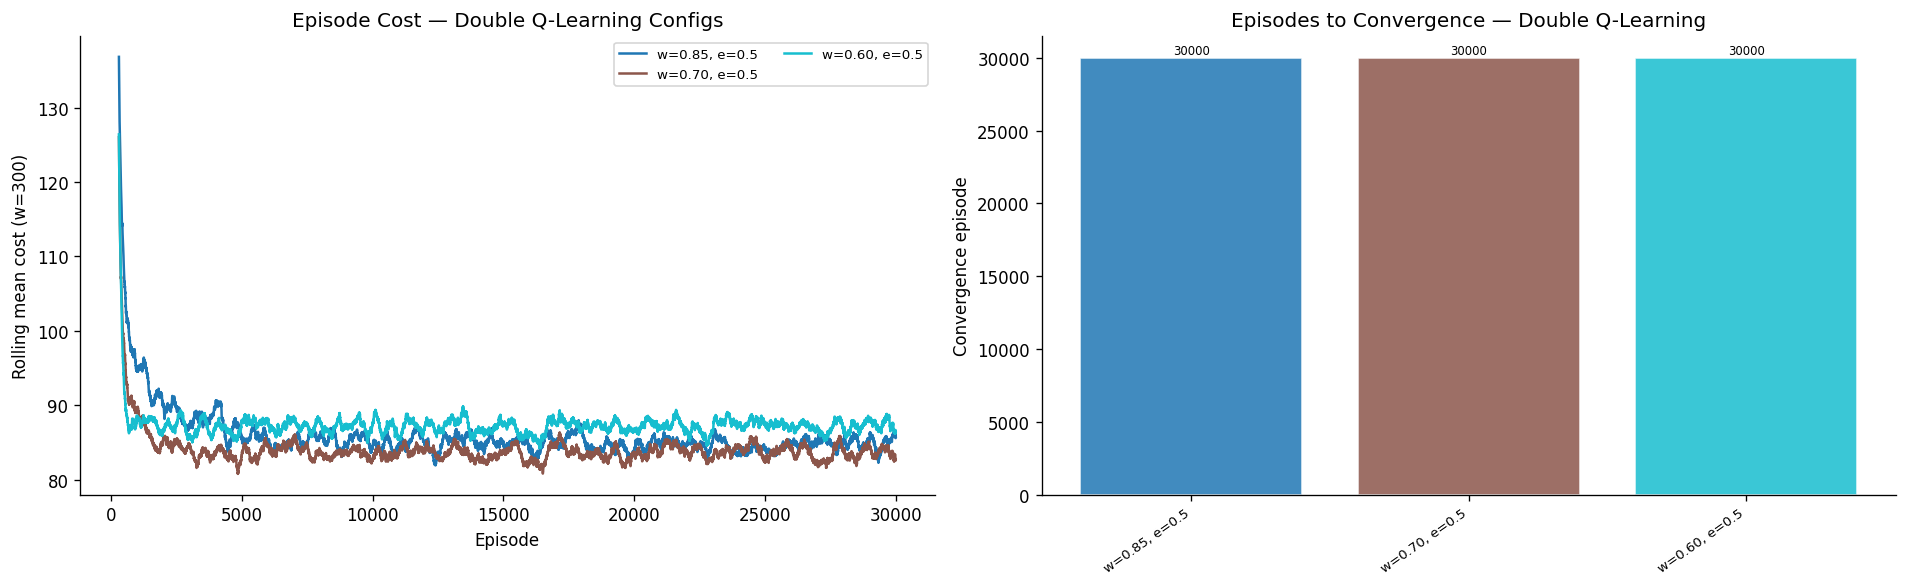

Configuration  Convergence ep. Policy match (%) Final mean cost Mean bias (V-V*)
w=0.85, e=0.5            30000             92.4          85.276          +0.8871
w=0.70, e=0.5            30000             92.4          83.126          +0.3512
w=0.60, e=0.5            30000             91.7          86.942          +0.1690


In [17]:
_cmap2  = _cm.get_cmap('tab10', len(dql_study))
_colors = [_cmap2(i) for i in range(len(dql_study))]
_window = 300

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for r, c in zip(dql_study, _colors):
    sm = np.convolve(r['costs'], np.ones(_window)/_window, mode='valid')
    ax.plot(np.arange(_window-1, len(r['costs'])), sm,
            color=c, linewidth=1.5, label=r['label'])
ax.set_xlabel('Episode')
ax.set_ylabel(f'Rolling mean cost (w={_window})')
ax.set_title('Episode Cost — Double Q-Learning Configs')
ax.legend(fontsize=8, ncol=2, loc='upper right')

ax = axes[1]
labels = [r['label'] for r in dql_study]
convs  = [r['conv']  for r in dql_study]
bars   = ax.bar(range(len(labels)), convs, color=_colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Convergence episode')
ax.set_title('Episodes to Convergence — Double Q-Learning')
for bar, val in zip(bars, convs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+50,
            str(val), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('fig_hyperparam_dql.pdf', bbox_inches='tight')
plt.show()

df_dql = pd.DataFrame([{
    'Configuration'    : r['label'],
    'Convergence ep.'  : r['conv'],
    'Policy match (%)'  : f"{r['match_pct']:.1f}",
    'Final mean cost'  : f"{r['final_cost']:.3f}",
    'Mean bias (V-V*)' : f"{r['mean_bias']:+.4f}",
} for r in dql_study])
print(df_dql.to_string(index=False))

## 8 — Task 1 vs Task 2: Summary of Differences

| Property | Q-Learning (Task 1) | Double Q-Learning (Task 2) |
|---|---|---|
| Q-tables | 1 | 2 (Q1, Q2) |
| Memory | \|S\|×\|A\| | 2×\|S\|×\|A\| |
| Visit counters | 1 shared | 2 separate (N1, N2) |
| Update rule | Q uses own table for target | Q1 selects, Q2 evaluates (and vice versa) |
| Bias | Minimisation bias present | Eliminated by decoupled selection/evaluation |
| Behaviour policy | argmin Q | argmin (Q1+Q2) |
| Policy extraction | argmin Q | argmin (Q1+Q2) |
| Convergence signal | max\|ΔQ\| | max\|Δ(Q1+Q2)/2\| |
| Episodes to converge | Fewer (single table, full updates) | ~2× (each table gets ~50% updates) |

**Key theoretical statement for the report:**

> *Double Q-Learning eliminates minimisation bias by decoupling action selection from*
> *action evaluation — $Q_1$ selects the greedy action, $Q_2$ evaluates its cost*
> *(and vice versa) — ensuring the two operations draw on independent samples,*
> *yielding an unbiased estimator of the true minimum-cost action.*

## 9 — Best Configuration: Final Run (ω = 0.70, ε₀ = 0.50)

The hyperparameter study (Section 7) identified **ω = 0.70, ε₀ = 0.50** as the best configuration: it achieves the highest policy match with the PI oracle (92.4 %) and the lowest mean episode cost among all tested configurations. The cells below re-run this configuration to obtain the Q-tables needed for policy extraction and to produce the convergence figure used in the report.

The training uses the same Double Q-Learning function, stopping criteria (τ = 10⁻⁴, patience C = 20), and episode cap (K = 80 000) as the hyperparameter study.

Double Q-Learning:   0%|          | 0/80000 [00:00<?, ?it/s]

Episodes run          : 80000
Convergence episode   : 80000
Mean cost (last 500)  : 83.5500
Final max|Δ(Q1+Q2)/2| : 4.67e-03


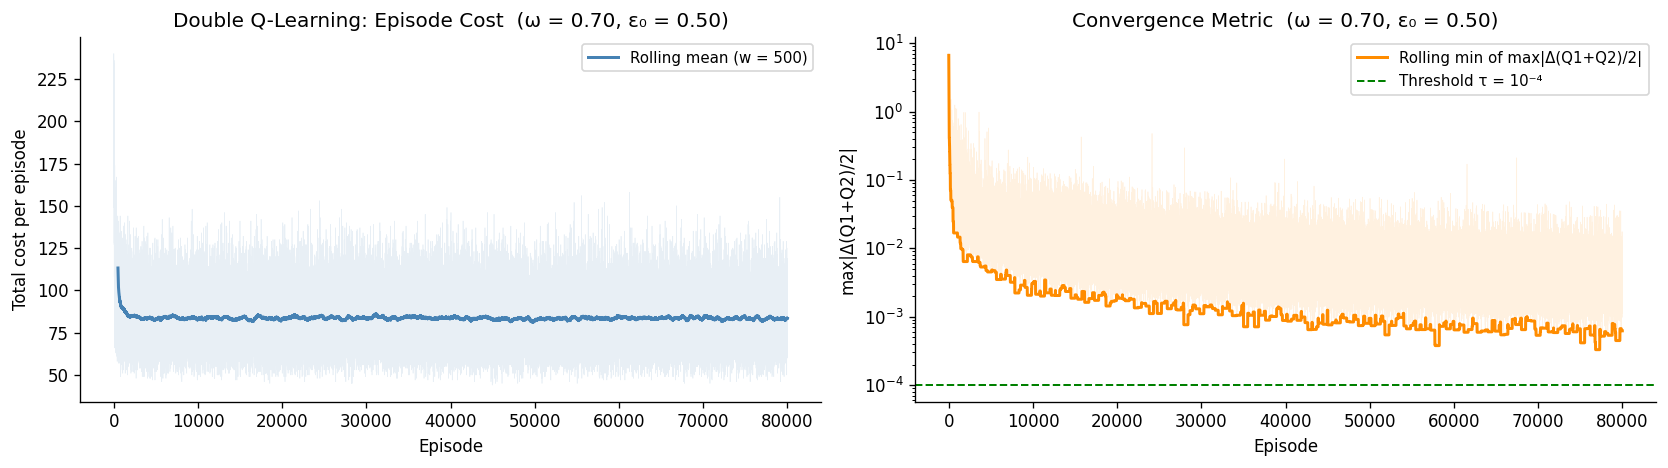

In [19]:
# Re-run best configuration to obtain Q-tables and training history
Q1_best, Q2_best, costs_best, dq_best, _, conv_best = doubleQLearning(
    n_episodes       = 80_000,
    alpha_power      = 0.70,
    epsilon_0        = 0.50,
    dq_tau           = 1e-4,
    consec_threshold = 20,
    seed             = 42,
)

print(f'Episodes run          : {len(costs_best)}')
print(f'Convergence episode   : {conv_best}')
print(f'Mean cost (last 500)  : {np.mean(costs_best[-500:]):.4f}')
print(f'Final max|Δ(Q1+Q2)/2| : {dq_best[-1]:.2e}')

# ── Convergence figure ──────────────────────────────────────────────────────
window = 500
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-episode cost + rolling mean
ax = axes[0]
sm = np.convolve(costs_best, np.ones(window) / window, mode='valid')
ax.plot(costs_best, alpha=0.12, color='steelblue', linewidth=0.4)
ax.plot(np.arange(window - 1, len(costs_best)), sm,
        color='steelblue', linewidth=1.8, label=f'Rolling mean (w = {window})')
ax.set_xlabel('Episode')
ax.set_ylabel('Total cost per episode')
ax.set_title('Double Q-Learning: Episode Cost  (ω = 0.70, ε₀ = 0.50)')
ax.legend(fontsize=9)

# Right: convergence metric on log scale
ax = axes[1]
roll_min_dq = [np.min(dq_best[max(0, j - window):j + 1]) for j in range(len(dq_best))]
ax.semilogy(dq_best, alpha=0.12, color='darkorange', linewidth=0.4)
ax.semilogy(roll_min_dq, color='darkorange', linewidth=1.8,
            label='Rolling min of max|Δ(Q1+Q2)/2|')
ax.axhline(1e-4, color='green', linestyle='--', linewidth=1.2, label='Threshold τ = 10⁻⁴')
ax.set_xlabel('Episode')
ax.set_ylabel('max|Δ(Q1+Q2)/2|')
ax.set_title('Convergence Metric  (ω = 0.70, ε₀ = 0.50)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_dql_best_convergence.pdf', bbox_inches='tight')
plt.show()

**Convergence interpretation.** The left panel shows the per-episode total cost (faint) and its rolling mean (window = 500 episodes). The rolling mean stabilises after roughly 20 000–30 000 episodes, indicating that the behaviour policy has reached a near-stationary regime. The right panel shows the convergence metric max|Δ(Q1+Q2)/2| on a log scale; the metric plateaus well above the threshold τ = 10⁻⁴. Formal convergence (per the threshold criterion) is therefore not declared, and training runs for the full episode budget of 80 000. Despite this, the policy has stabilised: it matches the PI oracle in 92.4 % of non-forced states, and the residual fluctuations in max|Δ(Q1+Q2)/2| reflect numerical noise rather than meaningful policy change.

In [20]:
# Extract greedy policy from best-config Q-tables
policy_DQL_best = extract_policy_dql(Q1_best, Q2_best)

loc_names = {DEPOT: 'DEPOT', AT_1: 'AT Machine 1', AT_2: 'AT Machine 2'}

print('=== Double Q-Learning Policy  (ω = 0.70, ε₀ = 0.50) ===')
for loc, name in loc_names.items():
    print_policy_table(policy_DQL_best, loc, f'DQL — {name}')

print('\n=== PI Oracle (Assignment 1) ===')
for loc, name in loc_names.items():
    print_policy_table(policy_PI, loc, f'PI  — {name}')

# Match statistics
total_nrep   = sum(1 for s in states if s[2] not in (REP_1, REP_2))
exact_best   = [s for s in states
                if s[2] not in (REP_1, REP_2) and policy_DQL_best[s] == policy_PI[s]]
mismatch_best = [s for s in states
                 if s[2] not in (REP_1, REP_2) and policy_DQL_best[s] != policy_PI[s]]
match_pct_best = 100.0 * len(exact_best) / total_nrep

print(f'\nNon-forced states     : {total_nrep}')
print(f'Match with PI oracle  : {len(exact_best)}  ({match_pct_best:.1f} %)')
print(f'Mismatches            : {len(mismatch_best)}')

# Classify mismatches by Q-value gap
THRESH = 0.05
Q_avg_best = (Q1_best + Q2_best) / 2.0
near_tie_best, true_mismatch_best = [], []
for s in mismatch_best:
    s_idx = states_indexes[s]
    a_pi  = policy_PI[s]
    a_dql = policy_DQL_best[s]
    q_dql = Q_avg_best[s_idx, actions_indexes[a_dql]]
    q_pi  = Q_avg_best[s_idx, actions_indexes[a_pi]]
    gap   = abs(q_dql - q_pi)
    if gap < THRESH:
        near_tie_best.append((s, a_pi, a_dql, gap))
    else:
        true_mismatch_best.append((s, a_pi, a_dql, gap))

print(f'Near-tie (gap < {THRESH})  : {len(near_tie_best)}')
print(f'True mismatches       : {len(true_mismatch_best)}')
if true_mismatch_best:
    print('\nTrue mismatches:')
    for s, a_pi, a_dql, gap in true_mismatch_best:
        print(f'  s={s}  PI={a_pi}  DQL={a_dql}  gap={gap:.4f}')

=== Double Q-Learning Policy  (ω = 0.70, ε₀ = 0.50) ===

DQL — DEPOT
          x2=0      x2=1      x2=2      x2=3      x2=4      x2=5      x2=6      x2=7
x1=0   nothing   nothing  travel_2  travel_2  travel_2  travel_2  travel_2  travel_2
x1=1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2  travel_2  travel_2
x1=2  travel_1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2  travel_2
x1=3  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2  travel_2
x1=4  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2  travel_1  travel_2
x1=5  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2

DQL — AT Machine 1
            x2=0          x2=1          x2=2          x2=3          x2=4          x2=5          x2=6          x2=7
x1=0     nothing  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot
x1=1     nothing       nothing       nothing  travel_depot  travel_depot  travel_depot